In [80]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city, plot_histogram
import matplotlib.pyplot as plt

In [81]:
# Параметри алгоритму Гровера
n = 3               # кількість кубітів пошуку
marked_state = '110' # стан, який потрібно знайти

In [82]:
# Функція для оракула Гровера
def grover_oracle(qc, marked_state):
    """Позначає стан marked_state, використовуючи додатковий таргет-кубіт"""
    num_qubits = len(marked_state)
    
    # Інвертуємо кубіти, де біт marked_state == 0
    for i, bit in enumerate(reversed(marked_state)):
        if bit == '0':
            qc.x(i)
    
    # Мульти-контрольований X (tarгет останній кубіт)
    qc.mcx(list(range(num_qubits)), num_qubits)
    
    # Відновлюємо інверсію для кубітів, де bit == 0
    for i, bit in enumerate(reversed(marked_state)):
        if bit == '0':
            qc.x(i)
    
    return qc

In [83]:
# Функція дифузора Гровера
def grover_diffuser(qc):
    """Застосовує дифузор Гровера (inversion about the mean)"""
    num_qubits = qc.num_qubits - 1  # останній кубіт – таргет
    qc.h(range(num_qubits))
    qc.x(range(num_qubits))
    qc.h(num_qubits - 1)
    qc.mcx(list(range(num_qubits - 1)), num_qubits - 1)
    qc.h(num_qubits - 1)
    qc.x(range(num_qubits))
    qc.h(range(num_qubits))
    return qc

In [84]:
# Квантова схема для statevector
qc_sv = QuantumCircuit(n + 1)   # n кубітів + 1 таргет-кубіт
qc_sv.h(range(n))               # Hadamard на всіх кубітах пошуку
qc_sv.x(n)                      # таргет-кубіт у стан |1>
qc_sv.h(n)                      # Hadamard на таргеті

# Виклик оракула
qc_sv = grover_oracle(qc_sv, marked_state)

# Застосування дифузора
qc_sv = grover_diffuser(qc_sv)

# Отримання statevector
state = Statevector.from_instruction(qc_sv)
print("Statevector:\n", state)

# Візуалізація statevector
plot_state_city(state)
plt.show()

Statevector:
 Statevector([-0.125+4.90653893e-18j, -0.125+4.90653893e-18j,
             -0.125+4.90653893e-18j, -0.125+4.90653893e-18j,
             -0.125-1.47196168e-17j, -0.125+4.90653893e-18j,
             -0.625-1.47196168e-17j, -0.125-1.47196168e-17j,
              0.125-4.90653893e-18j,  0.125-4.90653893e-18j,
              0.125-4.90653893e-18j,  0.125-4.90653893e-18j,
              0.125+1.47196168e-17j,  0.125-4.90653893e-18j,
              0.625+1.47196168e-17j,  0.125+1.47196168e-17j],
            dims=(2, 2, 2, 2))


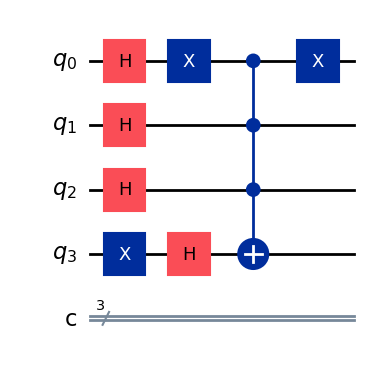

In [85]:
# Квантова схема QASM для вимірювання
qc = QuantumCircuit(n + 1, n)   # n кубітів + 1 таргет, n класичних бітів
qc.h(range(n))
qc.x(n)
qc.h(n)

# Виклик оракула
qc = grover_oracle(qc, marked_state)
qc.draw('mpl')

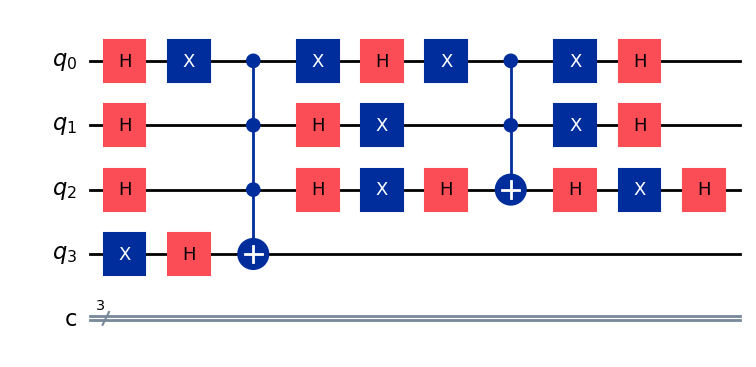

In [86]:
# Дифузор
qc = grover_diffuser(qc)
qc.draw('mpl')

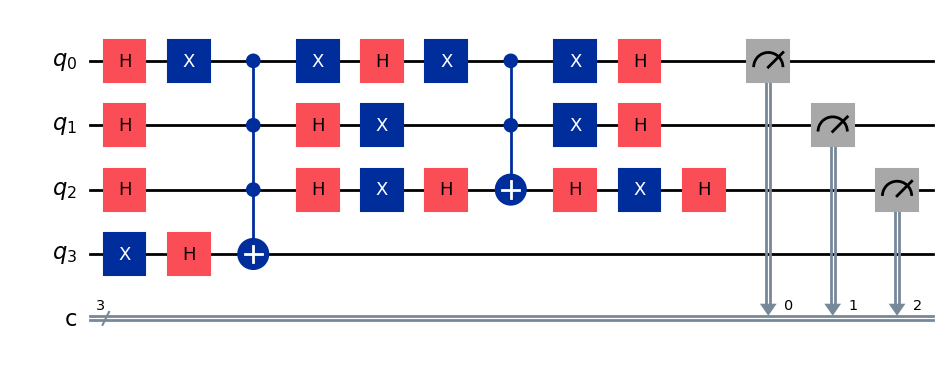

In [87]:
# Вимірювання
qc.measure(range(n), range(n))
qc.draw('mpl')

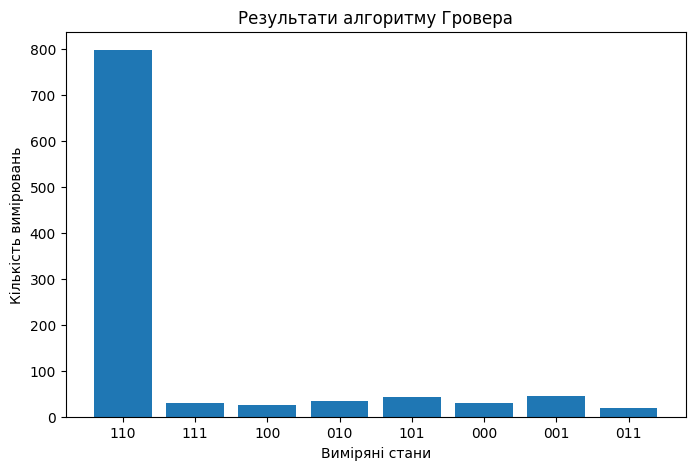

Counts: {'110': 797, '111': 29, '100': 26, '010': 34, '101': 43, '000': 30, '001': 45, '011': 20}
Знайдений стан: 110


In [88]:
# Симуляція з вимірюванням
backend_qasm = AerSimulator()
compiled_qasm = transpile(qc, backend_qasm)
job = backend_qasm.run(compiled_qasm, shots=1024)
counts = job.result().get_counts()

# Побудова гістограми
states = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(8,5))
plt.bar(states, values)
plt.xlabel("Виміряні стани")
plt.ylabel("Кількість вимірювань")
plt.title("Результати алгоритму Гровера")
plt.show()

# Виведення counts у консолі
print("Counts:", counts)

# Визначення знайденого стану
found_state = max(counts, key=counts.get)
print(f"Знайдений стан: {found_state}")